# Modern Portfolio Theory

Modern Portfolio Theory (MPT) is a foundational framework in financial economics that formalizes the process of constructing investment portfolios with optimal risk-return characteristics. First introduced by Harry Markowitz in the 1950s, MPT treats portfolio selection as a problem of statistical optimization, where diversification and covariance structure among assets are central to achieving efficient investment outcomes.

## Theoretical Foundations

MPT rests on the assumption that investors are rational and risk-averse, preferring higher expected returns for a given level of risk and lower risk for a given level of return. Risk is quantified as the variance or standard deviation of portfolio returns. In contrast to single-asset analysis, MPT recognizes that the risk of a portfolio depends not only on the individual variances of assets but also on the covariances between asset returns.

Let $R_i$ denote the random return of asset $i$, and let $w_i$ denote the portfolio weight allocated to asset $i$. The portfolio return $R_p$ is then

$$
R_p = \sum_i w_i R_i.
$$

The portfolio expected return is

$$
\mu_p = \sum_i w_i \mu_i,
$$

where $\mu_i = \mathbb{E}[R_i]$. The portfolio variance is

$$
\sigma_p^2 = \sum_i \sum_j w_i w_j \sigma_{ij},
$$

where $\sigma_{ij} = \text{Cov}(R_i, R_j)$.

## Efficient Frontier

The efficient frontier is the set of portfolios that offer the maximum expected return for a given level of risk or, equivalently, the minimum risk for a given expected return. These portfolios are obtained by solving a quadratic optimization problem subject to budget and return constraints.

In the mean-variance framework, the optimization problem can be expressed as:

- minimize $\frac{1}{2} w^\top \Sigma w$
- subject to $w^\top \mathbf{1} = 1$
- and $w^\top \mu = \mu_p$

where $w$ is the vector of portfolio weights, $\Sigma$ is the covariance matrix, $\mu$ is the vector of expected returns, and $\mathbf{1}$ is a vector of ones. The resulting frontier is typically a parabola in mean-variance space. The upper portion of this parabola constitutes the efficient frontier.

## Portfolio Diversification

Diversification in MPT arises from the reduction of portfolio variance through the combination of assets with imperfectly correlated returns. When asset correlations are less than one, the aggregate portfolio variance can be lower than the weighted sum of individual variances. Thus, a well-diversified portfolio can achieve a more favorable risk-return tradeoff than any single asset.

The diversification benefit is most pronounced when assets exhibit low or negative correlations. The extreme case of perfect positive correlation yields no diversification advantage, while lower correlations enhance the curvature of the efficient frontier, expanding the set of attainable efficient portfolios.

## The Role of the Risk-Free Asset

Introducing a risk-free asset with return $r_f$ simplifies the efficient frontier. Any combination of the risk-free asset and a given risky portfolio lies on a straight line in mean-standard deviation space, known as the capital market line (CML). The portfolio on the efficient frontier that is tangent to this line is the market portfolio. The slope of the CML, given by $(\mu_m - r_f) / \sigma_m$, is the Sharpe ratio of the market portfolio and represents the highest achievable reward-to-risk ratio.

### Capital Asset Pricing Model

The Capital Asset Pricing Model (CAPM) builds on MPT by introducing equilibrium conditions and a market equilibrium interpretation. CAPM asserts that in equilibrium, all investors hold combinations of the risk-free asset and the market portfolio. The expected return of an individual asset is then a linear function of its covariance with the market portfolio:

$$
\mathbb{E}[R_i] = r_f + \beta_i (\mathbb{E}[R_m] - r_f),
$$

where $\beta_i = \text{Cov}(R_i, R_m) / \sigma_m^2$. This relation defines the security market line (SML) and implies that asset risk is determined by systematic risk, while idiosyncratic risk can be diversified away.

### Arbitrage Pricing Theory

Arbitrage Pricing Theory (APT) extends the equilibrium insights of CAPM by allowing multiple systematic risk factors instead of a single market factor. Under APT, the expected return of asset $i$ is modeled as a linear function of its exposures to $K$ common risk factors:

$$
\mathbb{E}[R_i] = r_f + \beta_{i1} \lambda_1 + \beta_{i2} \lambda_2 + \cdots + \beta_{iK} \lambda_K,
$$

where $\beta_{ik}$ measures the sensitivity of asset $i$ to factor $k$, and $\lambda_k$ is the risk premium associated with factor $k$. APT relies on the absence of arbitrage in well-diversified portfolios, so that idiosyncratic risk is diversified away and only factor risk commands a premium.

In matrix form:

$$
\mathbb{E}[R] = r_f \mathbf{1} + B \lambda,
$$

where $B$ is the matrix of factor loadings and $\lambda$ is the vector of factor risk premia. Because APT does not require a specific market portfolio, it is more flexible than CAPM and can incorporate macroeconomic or statistical factors such as GDP growth, inflation, interest rates, or industry returns.

## Criticisms and Extensions

While MPT provides a rigorous quantitative foundation for portfolio selection, it is subject to several limitations:

- dependence on expected returns and covariances, which are difficult to estimate accurately;
- sensitivity to input assumptions, leading to unstable optimal portfolios;
- reliance on variance as the sole risk measure, which may not capture asymmetry or tail risk;
- assumption of normally distributed returns and quadratic utility.

Subsequent research has extended the mean-variance framework to accommodate alternative risk measures, robust optimization, and multi-period investment horizons. Behavioral finance also questions the assumption of investor rationality, suggesting that real-world portfolio choices may deviate from MPT prescriptions.

## Conclusion

Modern Portfolio Theory remains a cornerstone of contemporary finance, offering a coherent theoretical structure for understanding the benefits of diversification and the tradeoffs between risk and return. Its analytical clarity and mathematical elegance make it essential reading for students of investment theory, while its limitations motivate ongoing research into more realistic and robust portfolio construction methodologies.

[*********************100%***********************]  3 of 3 completed


Estimated factor risk premia:
SPY   -0.002918
IWM    0.005118
TLT   -0.005644
dtype: float64

Cross-sectional intercept:
0.007032564687783108

Estimated asset betas:
            SPY       IWM       TLT
AAPL   1.440513 -0.284088  0.061332
MSFT   1.557537 -0.499002 -0.076332
AMZN   1.723376 -0.271152 -0.114603
GOOGL  1.470648 -0.287384 -0.019892
TSLA   2.139271  0.082168 -0.026661


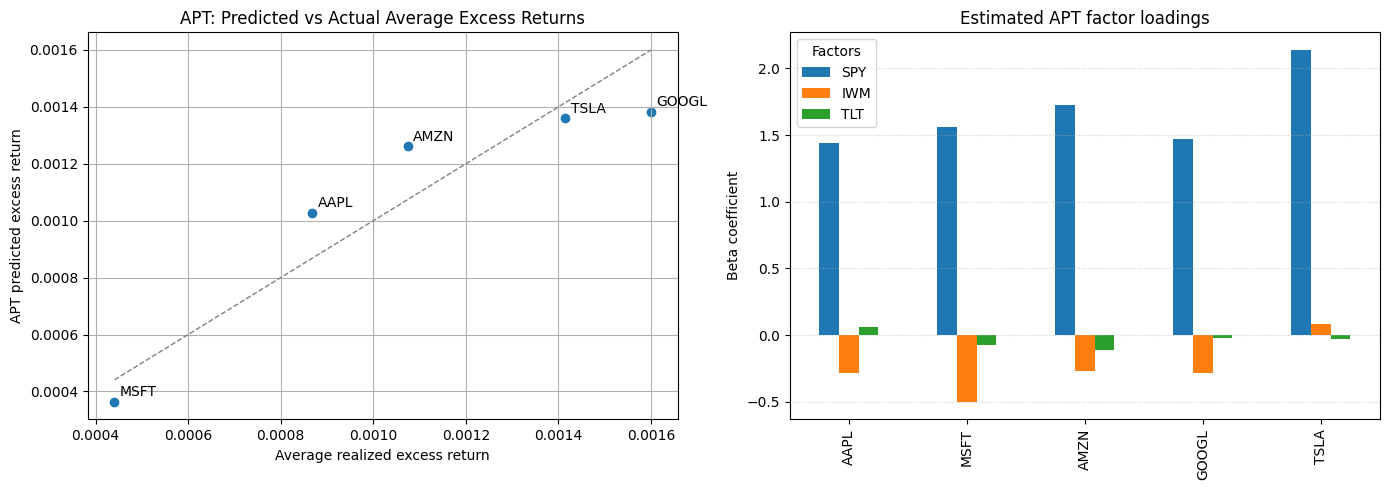

In [3]:
factor_tickers = ['SPY', 'IWM', 'TLT']

factor_prices = yf.download(factor_tickers, period='3y', interval='1d')['Close'].dropna()
factor_returns = factor_prices.pct_change().dropna()

common_dates = returns.index.intersection(factor_returns.index)
asset_returns = returns.loc[common_dates, tickers]
factor_returns = factor_returns.loc[common_dates, factor_tickers]

asset_excess = asset_returns
factor_excess = factor_returns

X = np.column_stack([factor_excess.values, np.ones(len(factor_excess))])
beta_list = []
intercepts = []
for asset in tickers:
    y = asset_excess[asset].values
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    beta_list.append(coef[:-1])
    intercepts.append(coef[-1])

betas = pd.DataFrame(beta_list, index=tickers, columns=factor_tickers)
intercepts = pd.Series(intercepts, index=tickers)

avg_excess = asset_excess.mean()
Z = np.column_stack([betas.values, np.ones(len(tickers))])
lambda_coef, *_ = np.linalg.lstsq(Z, avg_excess.values, rcond=None)

factor_premia = pd.Series(lambda_coef[:-1], index=factor_tickers)
cross_intercept = lambda_coef[-1]

predicted_excess = Z @ lambda_coef
predicted = pd.Series(predicted_excess, index=tickers)

print('Estimated factor risk premia:')
print(factor_premia)
print('\nCross-sectional intercept:')
print(cross_intercept)
print('\nEstimated asset betas:')
print(betas)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(avg_excess, predicted, color='tab:blue')
axes[0].plot([avg_excess.min(), avg_excess.max()],
             [avg_excess.min(), avg_excess.max()],
             color='gray', linestyle='--', linewidth=1)
for asset in tickers:
    axes[0].annotate(asset, (avg_excess[asset], predicted[asset]),
                     textcoords='offset points', xytext=(4, 4))
axes[0].set_xlabel('Average realized excess return')
axes[0].set_ylabel('APT predicted excess return')
axes[0].set_title('APT: Predicted vs Actual Average Excess Returns')
axes[0].grid(True)

betas.plot.bar(ax=axes[1])
axes[1].set_title('Estimated APT factor loadings')
axes[1].set_ylabel('Beta coefficient')
axes[1].legend(title='Factors')
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Minimum Variance Portfolio

## 1. Introduction

Within the Markowitz framework, investors seek to balance expected return against risk, where risk is commonly quantified by the variance of portfolio return. The minimum variance portfolio occupies a salient position on the efficient frontier, as it minimizes volatility without regard to expected return. In academic terms, it is the global minimum variance portfolio (GMVP) and serves as the lower bound of the attainable mean–variance locus.

## 2. Theoretical Foundations

Consider a universe of $n$ risky assets with return vector $R = (R_1, \ldots, R_n)^\top$, expected return vector $\mu = (\mu_1, \ldots, \mu_n)^\top$, and covariance matrix $\Sigma$, assumed positive definite. Let $w = (w_1, \ldots, w_n)^\top$ denote portfolio weights satisfying the budget constraint

$ \mathbf{1}^\top w = 1, $

where $\mathbf{1}$ is the $n$-dimensional vector of ones. The portfolio variance is given by

$ \sigma_p^2 = w^\top \Sigma w. $

The minimum variance portfolio is obtained by solving the quadratic program:

- minimize $ w^\top \Sigma w $
- subject to $ \mathbf{1}^\top w = 1. $

This problem has an analytical solution under the assumption that $\Sigma$ is non-singular.

## 3. Analytical Solution

Using the method of Lagrange multipliers, define the Lagrangian

$ \mathcal{L}(w, \lambda) = w^\top \Sigma w - \lambda (\mathbf{1}^\top w - 1). $

Setting the gradient with respect to $w$ to zero yields

$ 2 \Sigma w - \lambda \mathbf{1} = 0, $

hence

$ w = \frac{\lambda}{2} \Sigma^{-1} \mathbf{1}. $

Imposing the budget constraint gives

$ \lambda = \frac{2}{\mathbf{1}^\top \Sigma^{-1} \mathbf{1}}. $

Consequently, the minimum variance portfolio weights are

$ w^{\text{MV}} = \frac{\Sigma^{-1} \mathbf{1}}{\mathbf{1}^\top \Sigma^{-1} \mathbf{1}}. $

This expression highlights the central role of the inverse covariance matrix and the sensitivity of the GMVP to estimation error in $\Sigma$.

## 4. Properties and Interpretation

- The GMVP is independent of expected returns $\mu$; it is determined entirely by the covariance structure of asset returns.
- When asset returns are positively correlated, diversification benefits are attenuated, but the GMVP still exploits relative covariances to reduce portfolio variance.
- The GMVP weight vector may contain negative entries unless additional constraints (e.g., non-negativity) are imposed, reflecting the possibility of short positions in mean-variance optimization.

## 5. Estimation and Practical Considerations

In empirical applications, $\Sigma$ is estimated from historical return data. Common issues include:

- estimation error and sampling variability, especially with high-dimensional asset sets,
- non-stationarity of return covariances over time,
- the impact of missing data and asynchronous price observations,
- the need for regularization or shrinkage methods to improve the stability of $\Sigma^{-1}$.

Practitioners often complement the theoretical GMVP with robust covariance estimators, such as Ledoit–Wolf shrinkage, to mitigate the sensitivity of weights to noisy inputs.

## 6. Extensions

The minimum variance portfolio can be generalized by incorporating additional constraints:

- long-only constraints: $ w_i \ge 0 $ for all $i$,
- sector or factor exposure limits,
- transaction cost and turnover controls.

In the presence of a risk-free asset, the GMVP remains the tangency point of the lower envelope of risky portfolios and the capital market line when expected returns are adjusted appropriately.

## 7. Conclusion

The minimum variance portfolio is a key theoretical construct in modern portfolio theory. It formalizes the concept of the least risky portfolio within a given asset universe and serves as a reference point for efficient frontier analysis. Its practical relevance is tempered by estimation challenges, but its mathematical clarity makes it an indispensable element of academic and applied portfolio research.

[*********************100%***********************]  5 of 5 completed


Expected annual returns (mu):
Ticker
AAPL     0.218652
AMZN     0.270806
GOOGL    0.403251
MSFT     0.111093
TSLA     0.356426
dtype: float64

Annual covariance matrix (sigma):
Ticker      AAPL      AMZN     GOOGL      MSFT      TSLA
Ticker                                                  
AAPL    0.066901  0.034901  0.031962  0.024894  0.063001
AMZN    0.034901  0.096623  0.050210  0.040015  0.073633
GOOGL   0.031962  0.050210  0.088585  0.027142  0.066345
MSFT    0.024894  0.040015  0.027142  0.057603  0.048656
TSLA    0.063001  0.073633  0.066345  0.048656  0.335538

Minimum variance portfolio weights:
AAPL     0.366474
MSFT     0.026111
AMZN     0.204330
GOOGL    0.468149
TSLA    -0.065063
dtype: float64

Minimum variance portfolio expected return: 0.198415
Minimum variance portfolio volatility: 0.198783


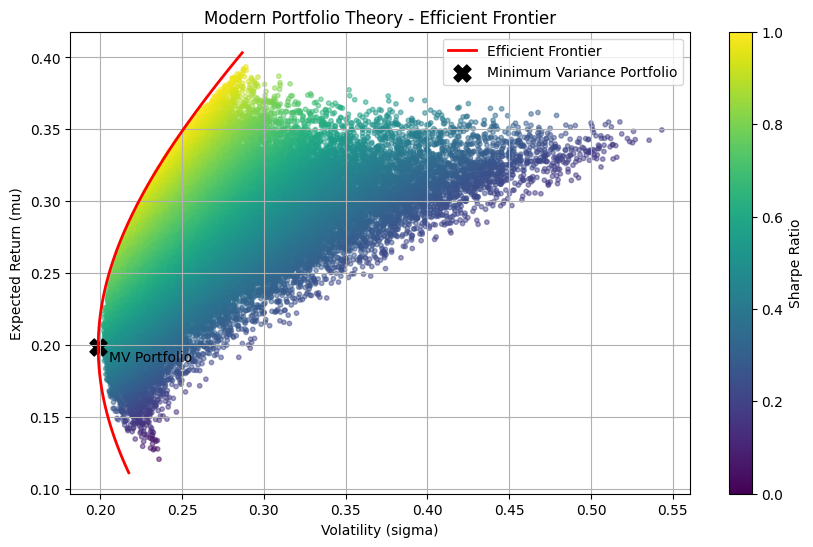

In [4]:
import yfinance as yf
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'TSLA']
prices = yf.download(tickers, period='3y', interval='1d')['Close'].dropna()
returns = prices.pct_change().dropna()

mu = returns.mean() * 252
sigma = returns.cov() * 252

print("Expected annual returns (mu):")
print(mu)
print("\nAnnual covariance matrix (sigma):")
print(sigma)

n = len(tickers)
Sigma = sigma.values
Sigma_inv = np.linalg.inv(Sigma)
ones = np.ones(n)

A = ones @ Sigma_inv @ ones
B = ones @ Sigma_inv @ mu.values
C = mu.values @ Sigma_inv @ mu.values
D = A * C - B**2

# Global minimum variance portfolio
w_mv = Sigma_inv @ ones / A
mv_return = w_mv @ mu.values
mv_vol = np.sqrt(w_mv @ Sigma @ w_mv)

print("\nMinimum variance portfolio weights:")
print(pd.Series(w_mv, index=tickers))
print(f"\nMinimum variance portfolio expected return: {mv_return:.6f}")
print(f"Minimum variance portfolio volatility: {mv_vol:.6f}")

target_returns = np.linspace(mu.min(), mu.max(), 100)
ef_vols = []
for tr in target_returns:
    lam = (C - B * tr) / D
    gamma = (A * tr - B) / D
    w = Sigma_inv @ (ones * lam + mu.values * gamma)
    ef_vols.append(np.sqrt(w @ Sigma @ w))

n_portfolios = 50000
weights = np.random.dirichlet(np.ones(n), n_portfolios)
port_returns = weights @ mu.values
port_vols = np.sqrt(np.einsum('ij,jk,ik->i', weights, Sigma, weights))

plt.figure(figsize=(10, 6))
plt.scatter(port_vols, port_returns, c=port_returns / port_vols, cmap='viridis', s=10, alpha=0.5)
plt.plot(ef_vols, target_returns, color='red', linewidth=2, label='Efficient Frontier')
plt.scatter([mv_vol], [mv_return], color='black', marker='X', s=150, label='Minimum Variance Portfolio')
plt.annotate('MV Portfolio', (mv_vol, mv_return), textcoords='offset points', xytext=(8, -10))

plt.xlabel('Volatility (sigma)')
plt.ylabel('Expected Return (mu)')
plt.title('Modern Portfolio Theory - Efficient Frontier')
plt.colorbar(label='Sharpe Ratio')
plt.legend()
plt.grid(True)
plt.show()